In [7]:
from pathlib import Path
import sys

# Allows the notebook to import files from the project root.
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import scienceplots
from src.preprocessing import load_csv, preprocess_data
from src.instantaneous_methods import (
    velocity_magnitude_method,
    velocity_acceleration_method,
    energy_method,
    work_method,
)

In [12]:
file_path = PROJECT_ROOT / "data" / "Seated_Global.csv"

df = load_csv(file_path)
data = preprocess_data(df, do_savgol=True)

In [15]:
results = {
    "VM": velocity_magnitude_method(data),

    "Velocity + acceleration": velocity_acceleration_method(
        data,
        acceleration_weight=0.1,
    ),

    "Energy": energy_method(
        data,
        hand_mass=0.4,
        kinetic_weight=0.85,
    ),

    "Work": work_method(
        data,
        hand_mass=0.4,
    ),
}

Plotting

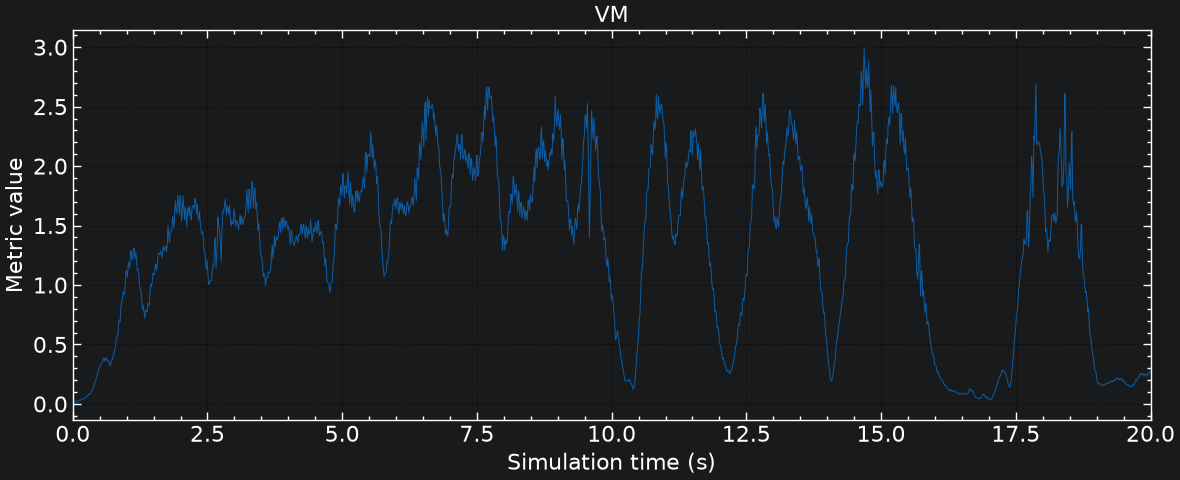

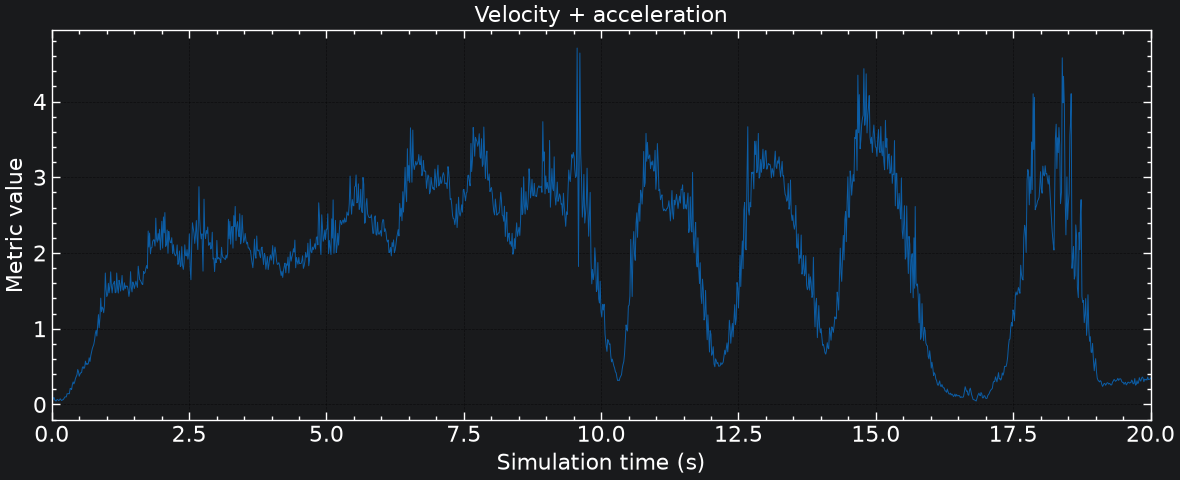

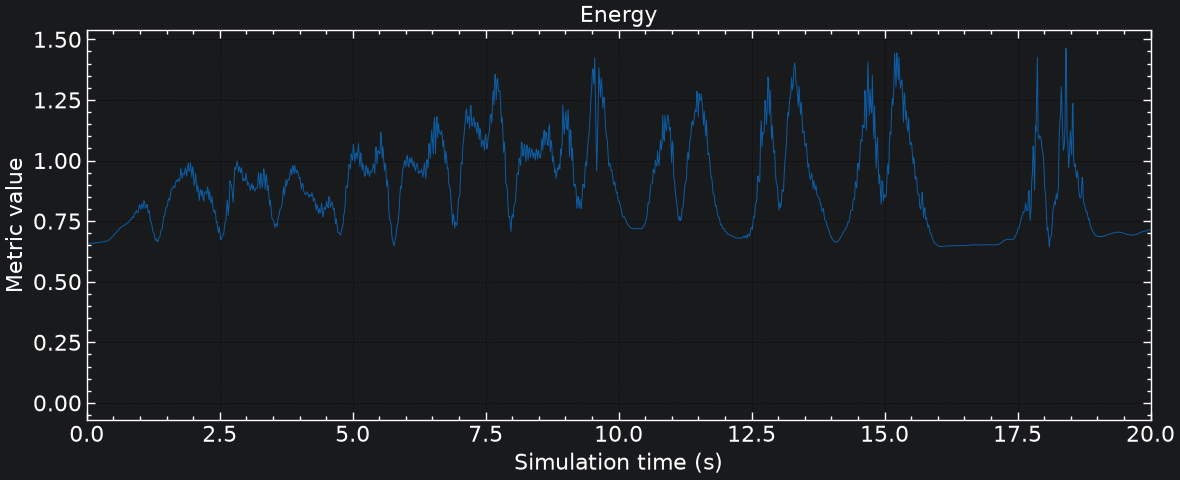

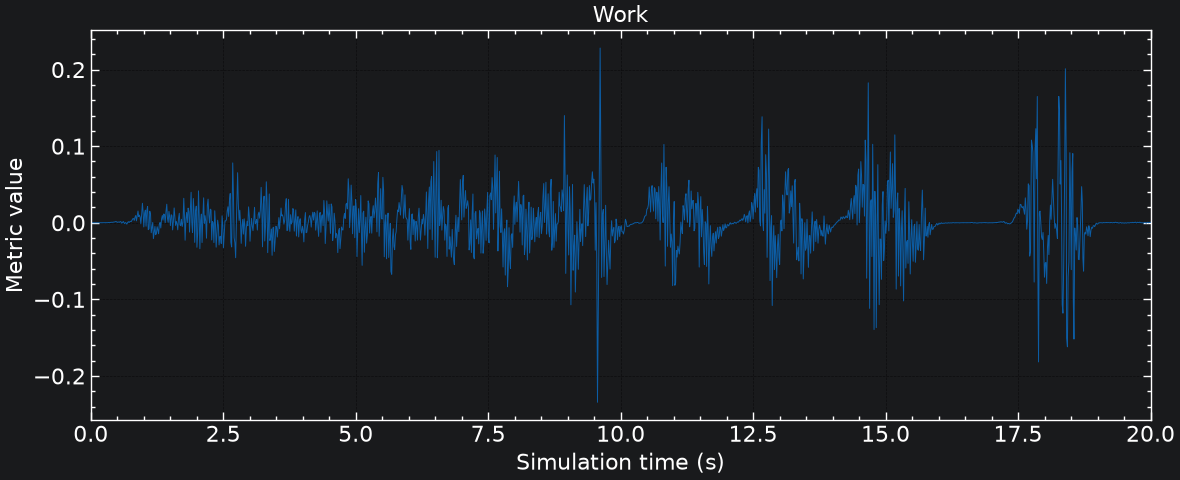

In [16]:
#start and end time to plot
plot_start_time = 0
plot_end_time = 20

for method_name, values in results.items():
    # Work has one fewer value because it describes changes
    # between consecutive frames.
    method_time = data["time"][:len(values)]
    plt.style.use(['science', 'notebook', 'grid'])
    plt.figure(figsize=(12, 5))
    plt.plot(method_time, values, linewidth=0.7)
    plt.xlim(plot_start_time, plot_end_time)
    plt.xlabel("Simulation time (s)")
    plt.ylabel("Metric value")
    plt.title(method_name)

    plt.tight_layout()
    plt.show()